CELL 1: Kết nối Google Drive, giải nén dữ liệu và sửa cấu trúc thư mục

In [2]:
import warnings
import os
import logging

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
logging.getLogger('tensorflow').setLevel(logging.ERROR)
from google.colab import drive
import zipfile, os, shutil

drive.mount('/content/drive')

zip_path    = '/content/drive/MyDrive/raw.zip'
extract_dir = '/content'

print('Đang giải nén...')
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

if os.path.exists('/content/raw/raw'):
    print('Phát hiện raw/raw → đang sửa lại cấu trúc...')
    shutil.move('/content/raw/raw', '/content/data')
    shutil.rmtree('/content/raw')
    print('Đã chuyển về: /content/data')

print('\nCấu trúc thư mục sau giải nén:')
base_path = '/content/data' if os.path.exists('/content/data') else '/content/raw'

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    if level <= 2:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')

print('\nThư mục chính:', base_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang giải nén...

Cấu trúc thư mục sau giải nén:
raw/
  train/
    surprise/
    angry/
    disgust/
    neutral/
    sad/
    fear/
    happy/
  test/
    surprise/
    angry/
    disgust/
    neutral/
    sad/
    fear/
    happy/

Thư mục chính: /content/raw


CELL 2: Thiết lập hằng số cấu hình

In [3]:
import os

BASE_DIR = '/content/data' if os.path.exists('/content/data') else '/content/raw'

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

SELECTED_LABELS = {
    'angry':    'Tức giận',
    'happy':    'Vui vẻ',
    'neutral':  'Bình thường',
    'sad':      'Buồn bã',
    'surprise': 'Bất ngờ',
}

IMG_SIZE    = (48, 48)
BATCH_SIZE  = 32
VAL_SPLIT   = 0.1

CELL 3: Thống kê phân bố các lớp và kiếm tra đặc tính dữ liệu

In [4]:
import os
from PIL import Image
def explore_dataset(base_dir, split_name):
    print(f'\n{"="*55}')
    print(f'  {split_name.upper()} SET')
    print(f'{"="*55}')
    total = 0

    for label in SELECTED_LABELS:
        folder = os.path.join(base_dir, label)

        if not os.path.exists(folder):
            print(f'  [!] Không tìm thấy: {folder}')
            continue

        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        total += len(files)

        if len(files) > 0:
            sample = Image.open(os.path.join(folder, files[0]))
            print(f'  {label:10s} | {len(files):5d} ảnh | '
                  f'size={sample.size} | mode={sample.mode} | '
                  f'format={sample.format}')
        else:
            print(f'  {label:10s} |     0 ảnh | [Thư mục rỗng]')

    print(f'  {"TOTAL":10s} | {total:5d} ảnh')
    return total

n_train = explore_dataset(TRAIN_DIR, 'train')
n_test  = explore_dataset(TEST_DIR,  'test')
print(f'\nTổng toàn bộ dataset: {n_train + n_test} ảnh')


  TRAIN SET
  angry      |  3982 ảnh | size=(48, 48) | mode=L | format=JPEG
  happy      |  7199 ảnh | size=(48, 48) | mode=L | format=JPEG
  neutral    |  4955 ảnh | size=(48, 48) | mode=L | format=JPEG
  sad        |  4825 ảnh | size=(48, 48) | mode=L | format=JPEG
  surprise   |  3165 ảnh | size=(48, 48) | mode=L | format=JPEG
  TOTAL      | 24126 ảnh

  TEST SET
  angry      |   956 ảnh | size=(48, 48) | mode=L | format=JPEG
  happy      |  1773 ảnh | size=(48, 48) | mode=L | format=JPEG
  neutral    |  1229 ảnh | size=(48, 48) | mode=L | format=JPEG
  sad        |  1247 ảnh | size=(48, 48) | mode=L | format=JPEG
  surprise   |   829 ảnh | size=(48, 48) | mode=L | format=JPEG
  TOTAL      |  6034 ảnh

Tổng toàn bộ dataset: 30160 ảnh


CELL 4: Trực quan hoá phân bố các lớp

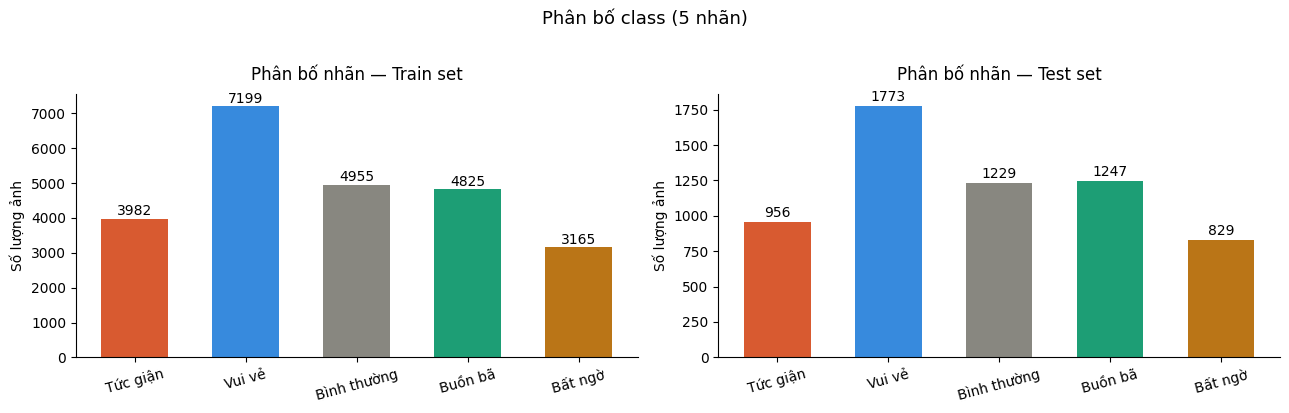

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#D85A30', '#378ADD', '#888780', '#1D9E75', '#BA7517']

for ax, (base_dir, title) in zip(axes, [(TRAIN_DIR, 'Train set'), (TEST_DIR, 'Test set')]):
    counts = {}
    for label, label_vi in SELECTED_LABELS.items():
        folder = os.path.join(base_dir, label)
        if os.path.exists(folder):
            counts[label_vi] = len([
                f for f in os.listdir(folder)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])

    labels_vi = list(counts.keys())
    values    = list(counts.values())

    bars = ax.bar(labels_vi, values, color=colors, edgecolor='none', width=0.6)

    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 15, str(v),
                ha='center', va='bottom', fontsize=10, fontweight='500')

    ax.set_title(f'Phân bố nhãn — {title}', fontsize=12, pad=10)
    ax.set_ylabel('Số lượng ảnh')
    ax.tick_params(axis='x', rotation=15)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Phân bố class (5 nhãn)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

CELL 5: Hiển thị mẫu dữ liệu các lớp

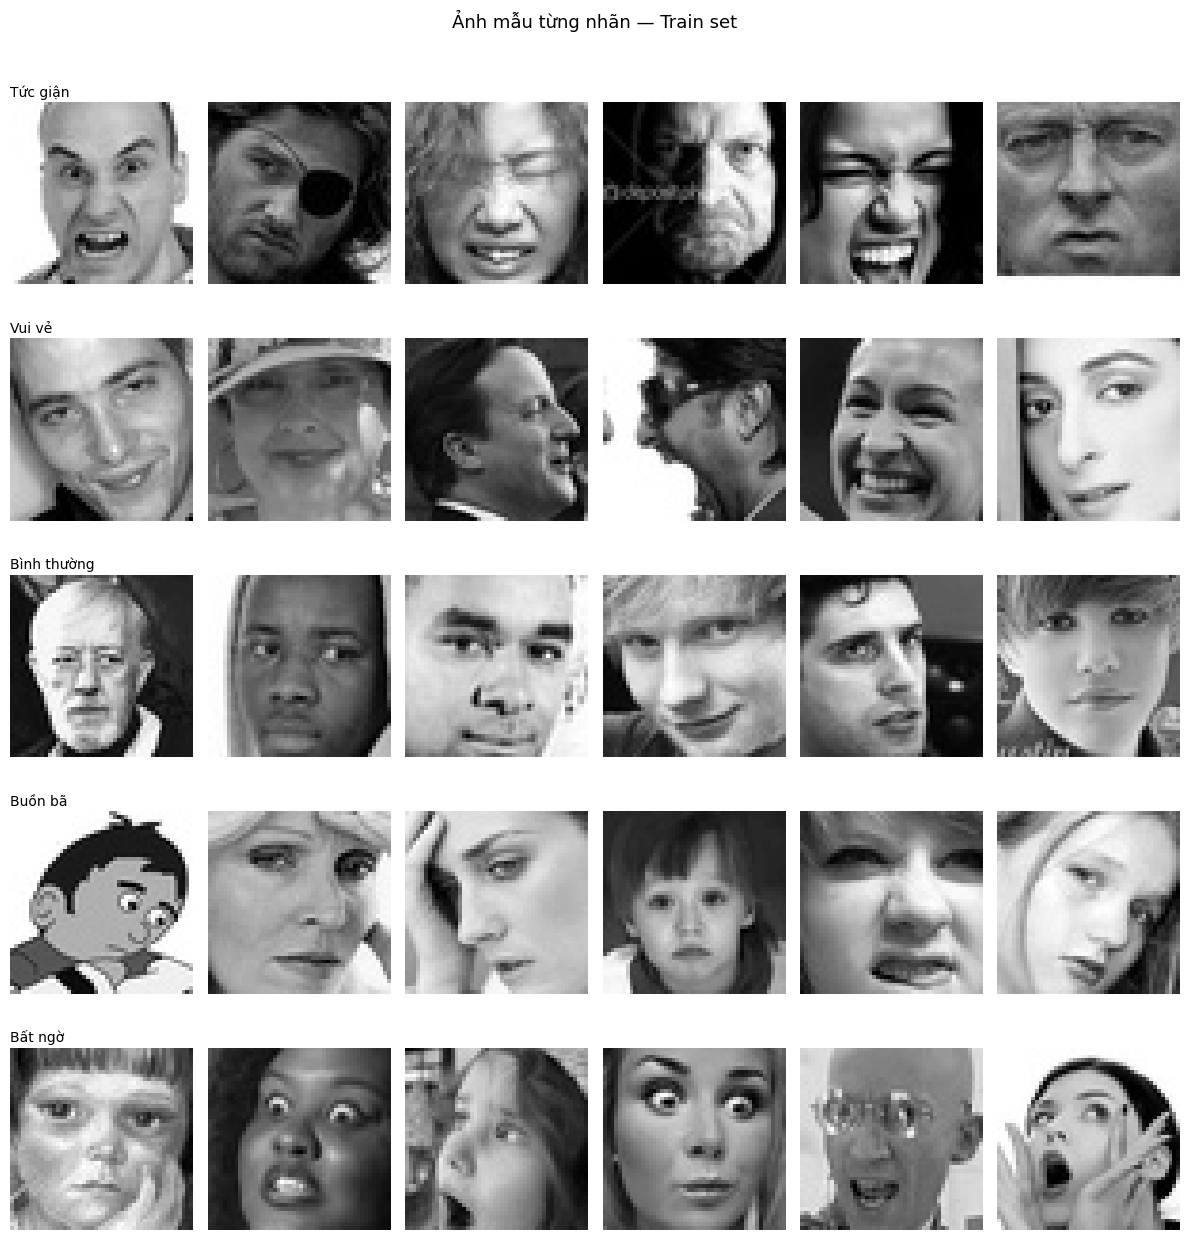

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import os
fig, axes = plt.subplots(len(SELECTED_LABELS), 6, figsize=(12, 2.5 * len(SELECTED_LABELS)))

for ax_row in axes:
    for ax in ax_row:
        ax.axis('off')

for row_idx, (label, label_vi) in enumerate(SELECTED_LABELS.items()):
    folder = os.path.join(TRAIN_DIR, label)

    if not os.path.exists(folder):
        continue

    files  = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:6]

    for col_idx, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname))
        axes[row_idx, col_idx].imshow(img, cmap='gray')

        if col_idx == 0:
            axes[row_idx, col_idx].set_title(label_vi, fontsize=10, loc='left', pad=4, fontweight='500')

plt.suptitle('Ảnh mẫu từng nhãn — Train set', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

CELL 6: Thiết lập băng chuyền dữ liệu(Rescaling, Data Augmentation, Train/Val Split)

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    validation_split=VAL_SPLIT
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

test_datagen = ImageDataGenerator(rescale=1./255)

CELL 7: Trực quan hoá Data Augmentation

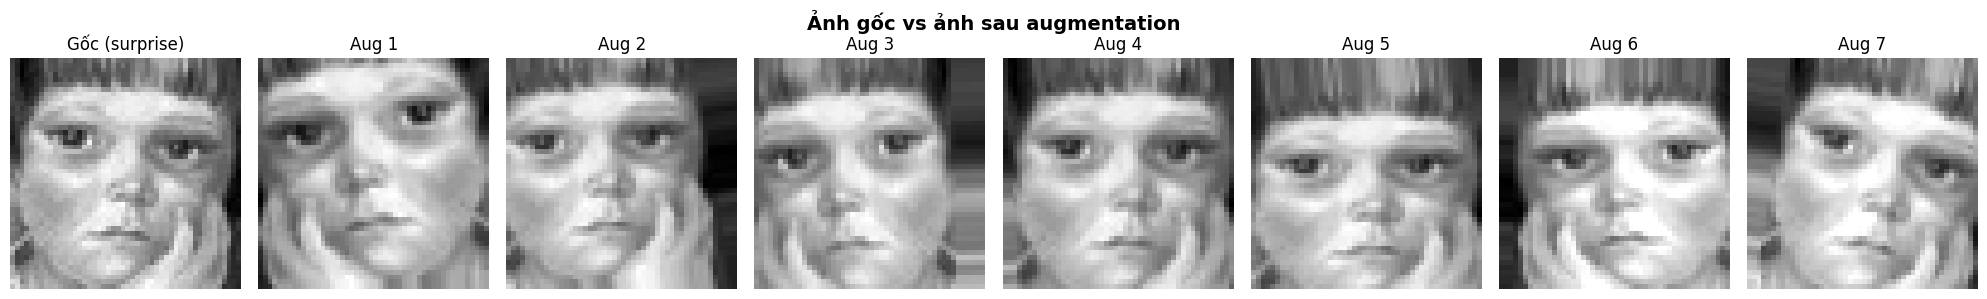

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

try:
    first_folder = os.listdir(TRAIN_DIR)[0]
    first_img_name = os.listdir(os.path.join(TRAIN_DIR, first_folder))[0]
    auto_img_path = os.path.join(TRAIN_DIR, first_folder, first_img_name)

    img = load_img(auto_img_path, target_size=IMG_SIZE, color_mode='grayscale')
    img_array = img_to_array(img)
    img_array_batch = np.expand_dims(img_array, axis=0)

    aug_iterator = train_datagen.flow(img_array_batch, batch_size=1)

    fig, axes = plt.subplots(1, 8, figsize=(20, 3))
    fig.suptitle('Ảnh gốc vs ảnh sau augmentation', fontsize=14, fontweight='bold')

    axes[0].imshow(np.squeeze(img_array) / 255.0, cmap='gray')
    axes[0].set_title(f'Gốc ({first_folder})')
    axes[0].axis('off')

    for i in range(1, 8):
        aug_img = next(aug_iterator)[0]
        axes[i].imshow(np.squeeze(aug_img), cmap='gray')
        axes[i].set_title(f'Aug {i}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Không thể in ảnh trực quan do lỗi: {e}")

CELL 8: HÚT DỮ LIỆU TỪ Ổ CỨNG VÀO BĂNG CHUYỀN (Filtering, Resizing, Grayscale, Data spliting, One - Hot Encoding, Batching & Shuffling)

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("Bắt đầu nạp luồng dữ liệu...")

label_keys = list(SELECTED_LABELS.keys())
SEED = 42

print("\n1. Đang nạp tập TRAIN (90%):")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=label_keys,
    subset='training',
    seed=SEED,
    shuffle=True
)

print("\n2. Đang nạp tập VALIDATION (10% trích ra từ Train):")
val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=label_keys,
    subset='validation',
    seed=SEED,
    shuffle=False
)

print("\n3. Đang nạp tập TEST:")
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=label_keys,
    shuffle=False
)

Bắt đầu nạp luồng dữ liệu...

1. Đang nạp tập TRAIN (90%):
Found 21716 images belonging to 5 classes.

2. Đang nạp tập VALIDATION (10% trích ra từ Train):
Found 2410 images belonging to 5 classes.

3. Đang nạp tập TEST:
Found 6034 images belonging to 5 classes.


CELL 9: Tính toán trọng số lớp (Class Weight)

In [10]:
from sklearn.utils import class_weight
import numpy as np

train_labels = train_generator.classes

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights_dict = dict(enumerate(weights))

print("Đã tính toán Class Weights:")
print("-" * 50)
for idx, w in class_weights_dict.items():
    label_name = list(SELECTED_LABELS.keys())[idx]
    print(f"   → Nhãn {idx} ({label_name:10s}): {w:.4f}")
print("-" * 50)

Đã tính toán Class Weights:
--------------------------------------------------
   → Nhãn 0 (angry     ): 1.2118
   → Nhãn 1 (happy     ): 0.6702
   → Nhãn 2 (neutral   ): 0.9738
   → Nhãn 3 (sad       ): 1.0000
   → Nhãn 4 (surprise  ): 1.5245
--------------------------------------------------


CELL 10: So sánh các kiến trúc DeepLearning

In [11]:
import pandas as pd
from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, MaxPooling2D, Dropout, BatchNormalization, Resizing
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.vgg16 import preprocess_input

def build_custom_cnn():
    model = Sequential(name='CNN')
    model.add(Conv2D(64, (3, 3), padding='same', activation='elu', kernel_initializer='he_normal', input_shape=(48, 48, 1)))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), padding='same', activation='elu', kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2))

    model.add(Conv2D(128, (3, 3), padding='same', activation='elu', kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), padding='same', activation='elu', kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))

    model.add(Conv2D(256, (3, 3), padding='same', activation='elu', kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3, 3), padding='same', activation='elu', kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.4))

    model.add(Flatten())
    model.add(Dense(256, activation='elu', kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(128, activation='elu', kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(5, activation='softmax'))

    model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_mobilenetv2():
    in_layer = Input(shape=(48, 48, 1))

    x = Resizing(96, 96)(in_layer)
    x = Conv2D(3, (3,3), padding='same')(x)

    base_model = MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights=None
    )

    x = base_model(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    out_layer = Dense(5, activation='softmax')(x)

    model = Model(inputs=in_layer, outputs=out_layer, name="MobileNetV2")
    model.compile(optimizer=optimizers.Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def build_vgg16():
    in_layer = Input(shape=(48, 48, 1))

    x = Resizing(96, 96)(in_layer)
    x = Conv2D(3, (3,3), padding='same')(x)

    base_model = VGG16(
        input_shape=(96, 96, 3),
        include_top=False,
        weights=None
    )

    x = base_model(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    out_layer = Dense(5, activation='softmax')(x)

    model = Model(inputs=in_layer, outputs=out_layer, name="VGG16")
    model.compile(optimizer=optimizers.Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

compare_results = []

list_models = [build_custom_cnn(), build_mobilenetv2(), build_vgg16()]

early_stop_compare = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_compare = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

for m in list_models:
    print(f"\nĐang bắt đầu thử nghiệm: {m.name}...")

    train_generator.reset()
    val_generator.reset()

    history = m.fit(train_generator, validation_data=val_generator, epochs=10,
    class_weight=class_weights_dict, callbacks=[early_stop_compare, reduce_lr_compare],
    verbose=1)

    compare_results.append({
        'Algorithm': m.name,
        'Accuracy': max(history.history['val_accuracy']),
    })

df_compare = pd.DataFrame(compare_results)

print("\nBẢNG TỔNG HỢP KẾT QUẢ:")
print(df_compare[['Algorithm', 'Accuracy']].to_string(index=False))


Đang bắt đầu thử nghiệm: CNN...
Epoch 1/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 55s 55ms/step - accuracy: 0.2484 - loss: 2.1834 - val_accuracy: 0.4021 - val_loss: 1.4655 - learning_rate: 1.0000e-04
Epoch 2/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.2804 - loss: 1.8899 - val_accuracy: 0.4228 - val_loss: 1.4215 - learning_rate: 1.0000e-04
Epoch 3/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.3186 - loss: 1.7452 - val_accuracy: 0.4357 - val_loss: 1.4199 - learning_rate: 1.0000e-04
Epoch 4/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.3465 - loss: 1.6292 - val_accuracy: 0.4950 - val_loss: 1.2989 - learning_rate: 1.0000e-04
Epoch 5/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.3765 - loss: 1.5308 - val_accuracy: 0.5058 - val_loss: 1.2753 - learning_rate: 1.0000e-04
Epoch 6/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.4026 - loss: 1.4587 - val_accuracy: 0.5187 - val_loss: 1.2383 - learning_rate: 1.0000e-04
Epoch 7/10
679/679 

CELL 11: Biểu đồ so sánh các cấu trúc DeepLearning

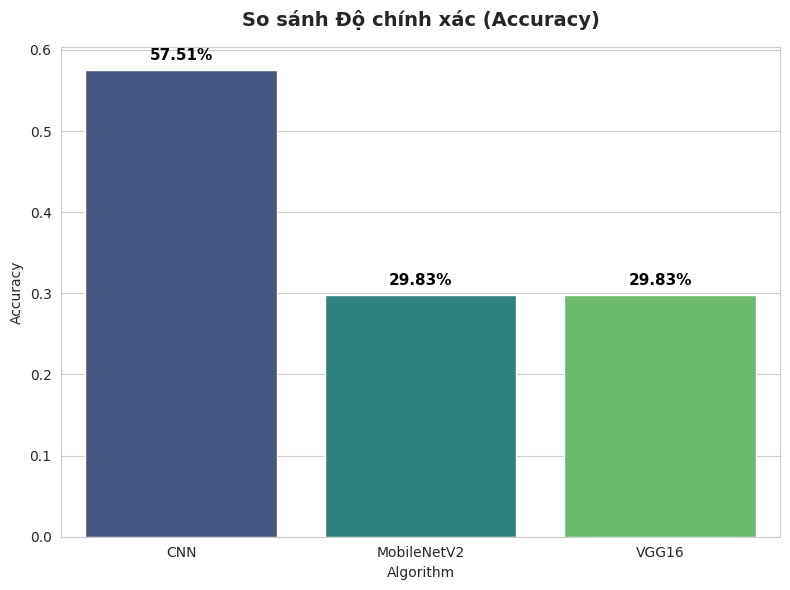

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

ax1 = sns.barplot(x='Algorithm', y='Accuracy', data=df_compare, palette='viridis')
plt.title('So sánh Độ chính xác (Accuracy)', fontsize=14, fontweight='bold', pad=15)

for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2%}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom',
                 fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

CELL 12: Xây dựng mô hình tốt nhất

In [13]:
best_model_name = df_compare.sort_values(by='Accuracy', ascending=False).iloc[0]['Algorithm']
print(f"Mô hình tốt nhất: {best_model_name}")

if best_model_name == 'CNN':
    model = build_custom_cnn()
elif best_model_name == 'MobileNetV2':
    model = build_mobilenetv2()
else:
    model = build_vgg16()

Mô hình tốt nhất: CNN


CELL 13: Chi tiết cấu trúc mô hình tốt nhất

In [14]:
print(f"\n=== CẤU TRÚC MÔ HÌNH: {best_model_name} ===")
model.summary()


=== CẤU TRÚC MÔ HÌNH: CNN ===


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,542,469 (13.51 MB)

 Trainable params: 3,539,909 (13.50 MB)

 Non-trainable params: 2,560 (10.00 KB)

CELL 14: Thiết lập hàm gọi lại (CallBacks)

In [15]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

checkpoint = ModelCheckpoint(
    filepath='saved_models/best_fer_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks_list = [checkpoint, early_stop, reduce_lr]

CELL 15: Huấn luyện mô hình

In [16]:
print("Bắt đầu quá trình huấn luyện chuyên sâu...")

EPOCHS = 50

history_final = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    class_weight=class_weights_dict,
    verbose=1
)

model.save('saved_models/final_fer_model.h5')

Bắt đầu quá trình huấn luyện chuyên sâu...
Epoch 1/50
678/679 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2310 - loss: 2.2956
Epoch 1: val_accuracy improved from None to 0.35726, saving model to saved_models/best_fer_model.h5



Epoch 1: finished saving model to saved_models/best_fer_model.h5
679/679 ━━━━━━━━━━━━━━━━━━━━ 49s 53ms/step - accuracy: 0.2432 - loss: 2.1533 - val_accuracy: 0.3573 - val_loss: 1.5283 - learning_rate: 1.0000e-04
Epoch 2/50
678/679 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2813 - loss: 1.9084
Epoch 2: val_accuracy improved from 0.35726 to 0.40788, saving model to saved_models/best_fer_model.h5



Epoch 2: finished saving model to saved_models/best_fer_model.h5
679/679 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.2779 - loss: 1.8735 - val_accuracy: 0.4079 - val_loss: 1.4340 - learning_rate: 1.0000e-04
Epoch 3/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3057 - loss: 1.7508
Epoch 3: val_accuracy improved from 0.40788 to 0.45353, saving model to saved_models/best_fer_model.h5



Epoch 3: finished saving model to saved_models/best_fer_model.h5
679/679 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.3104 - loss: 1.7331 - val_accuracy: 0.4535 - val_loss: 1.3998 - learning_rate: 1.0000e-04
Epoch 4/50
678/679 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3353 - loss: 1.6362
Epoch 4: val_accuracy improved from 0.45353 to 0.47801, saving model to saved_models/best_fer_model.h5



Epoch 4: finished saving model to saved_models/best_fer_model.h5
679/679 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.3371 - loss: 1.6246 - val_accuracy: 0.4780 - val_loss: 1.3027 - learning_rate: 1.0000e-04
Epoch 5/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3665 - loss: 1.5480
Epoch 5: val_accuracy did not improve from 0.47801
679/679 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.3700 - loss: 1.5292 - val_accuracy: 0.4577 - val_loss: 1.3773 - learning_rate: 1.0000e-04
Epoch 6/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3791 - loss: 1.5008
Epoch 6: val_accuracy improved from 0.47801 to 0.50415, saving model to saved_models/best_fer_model.h5


...


Epoch 34: finished saving model to saved_models/best_fer_model.h5
679/679 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.6835 - loss: 0.8281 - val_accuracy: 0.6983 - val_loss: 0.7787 - learning_rate: 5.0000e-05
Epoch 35/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6865 - loss: 0.8193
Epoch 35: val_accuracy did not improve from 0.69834
679/679 ━━━━━━━━━━━━━━━━━━━━ 36s 52ms/step - accuracy: 0.6865 - loss: 0.8184 - val_accuracy: 0.6983 - val_loss: 0.7875 - learning_rate: 5.0000e-05
Epoch 36/50
678/679 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6924 - loss: 0.8092
Epoch 36: val_accuracy did not improve from 0.69834
679/679 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.6889 - loss: 0.8182 - val_accuracy: 0.6975 - val_loss: 0.7870 - learning_rate: 5.0000e-05
Epoch 37/50
678/679 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6862 - loss: 0.8180
Epoch 37: val_accuracy did not improve from 0.69834
679/679 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.6876 - loss: 0.


Epoch 39: finished saving model to saved_models/best_fer_model.h5
679/679 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - accuracy: 0.6910 - loss: 0.8059 - val_accuracy: 0.7029 - val_loss: 0.7689 - learning_rate: 5.0000e-05
Epoch 40/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6997 - loss: 0.7858
Epoch 40: val_accuracy did not improve from 0.70290
679/679 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.6941 - loss: 0.8016 - val_accuracy: 0.7008 - val_loss: 0.7756 - learning_rate: 5.0000e-05
Epoch 41/50
678/679 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6974 - loss: 0.7959
Epoch 41: val_accuracy improved from 0.70290 to 0.70622, saving model to saved_models/best_fer_model.h5



Epoch 41: finished saving model to saved_models/best_fer_model.h5
679/679 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.6985 - loss: 0.7947 - val_accuracy: 0.7062 - val_loss: 0.7552 - learning_rate: 5.0000e-05
Epoch 42/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6986 - loss: 0.7921
Epoch 42: val_accuracy did not improve from 0.70622
679/679 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.7001 - loss: 0.7953 - val_accuracy: 0.7050 - val_loss: 0.7742 - learning_rate: 5.0000e-05
Epoch 43/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6997 - loss: 0.7833
Epoch 43: val_accuracy did not improve from 0.70622
679/679 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.6992 - loss: 0.7915 - val_accuracy: 0.7054 - val_loss: 0.7568 - learning_rate: 5.0000e-05
Epoch 44/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6962 - loss: 0.7918
Epoch 44: val_accuracy did not improve from 0.70622
679/679 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.7005 - loss: 0.


Epoch 46: finished saving model to saved_models/best_fer_model.h5

Epoch 46: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
679/679 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.7056 - loss: 0.7757 - val_accuracy: 0.7141 - val_loss: 0.7569 - learning_rate: 5.0000e-05
Epoch 47/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7033 - loss: 0.7744
Epoch 47: val_accuracy did not improve from 0.71411
679/679 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.7052 - loss: 0.7688 - val_accuracy: 0.7129 - val_loss: 0.7515 - learning_rate: 2.5000e-05
Epoch 48/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7090 - loss: 0.7701
Epoch 48: val_accuracy improved from 0.71411 to 0.71618, saving model to saved_models/best_fer_model.h5



Epoch 48: finished saving model to saved_models/best_fer_model.h5
679/679 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.7075 - loss: 0.7656 - val_accuracy: 0.7162 - val_loss: 0.7511 - learning_rate: 2.5000e-05
Epoch 49/50
678/679 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7127 - loss: 0.7567
Epoch 49: val_accuracy did not improve from 0.71618
679/679 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.7127 - loss: 0.7605 - val_accuracy: 0.7129 - val_loss: 0.7568 - learning_rate: 2.5000e-05
Epoch 50/50
678/679 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7134 - loss: 0.7555
Epoch 50: val_accuracy did not improve from 0.71618
679/679 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.7130 - loss: 0.7622 - val_accuracy: 0.7154 - val_loss: 0.7482 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 50.


CELL 16: Biểu đồ Accuracy và Loss

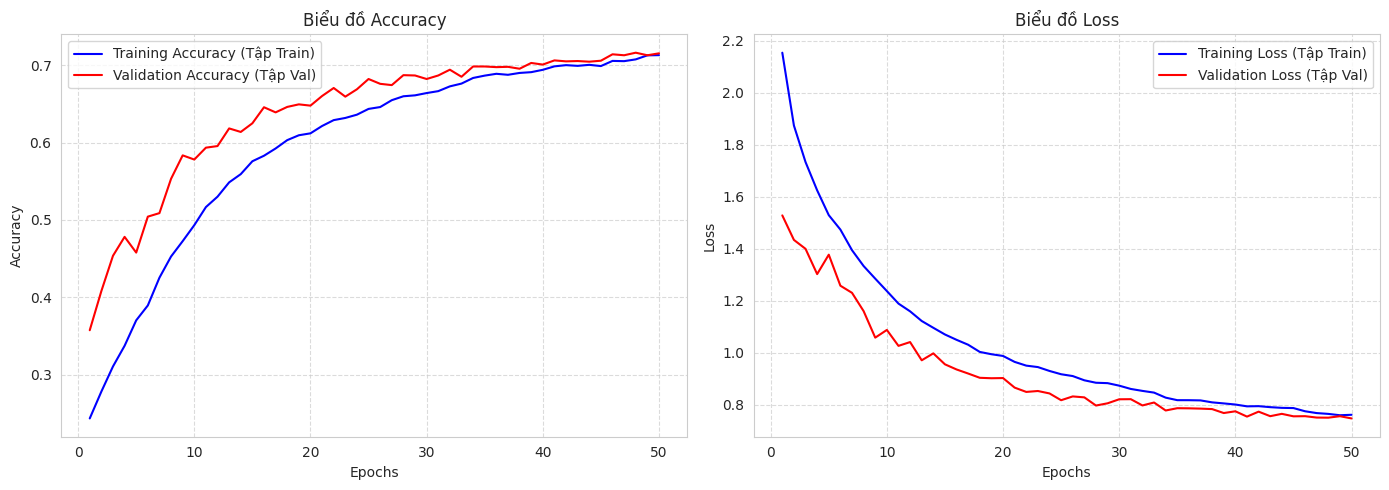

In [17]:
import matplotlib.pyplot as plt

acc = history_final.history['accuracy']
val_acc = history_final.history['val_accuracy']
loss = history_final.history['loss']
val_loss = history_final.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy (Tập Train)')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy (Tập Val)')
plt.title('Biểu đồ Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss (Tập Train)')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss (Tập Val)')
plt.title('Biểu đồ Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

CELL 17: Báo cáo phân loại (Classificatin Report)

In [18]:
import numpy as np
from sklearn.metrics import classification_report

print("Đang dự đoán trên tập TEST...")
test_generator.reset()

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print("\nBÁO CÁO PHÂN LOẠI:")
print(classification_report(y_true, y_pred, target_names=class_names))

Đang dự đoán trên tập TEST...
189/189 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step

BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

       angry       0.65      0.67      0.66       956
       happy       0.90      0.81      0.86      1773
     neutral       0.56      0.77      0.65      1229
         sad       0.68      0.48      0.56      1247
    surprise       0.81      0.88      0.84       829

    accuracy                           0.72      6034
   macro avg       0.72      0.72      0.71      6034
weighted avg       0.74      0.72      0.72      6034



CELL 18: Ma trận nhầm lẫn (Confusion Matrix)

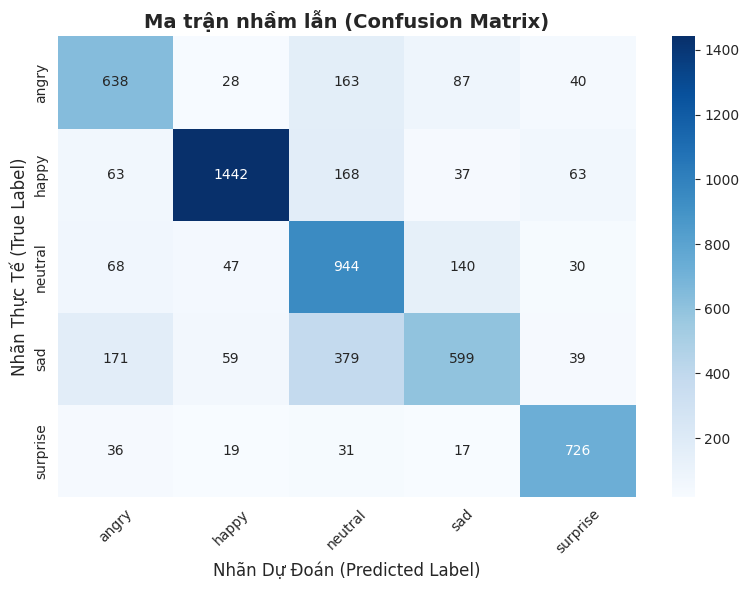

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14, fontweight='bold')
plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12)
plt.xlabel('Nhãn Dự Đoán (Predicted Label)', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

CELL 19: Đánh giá tổng thể trên tập Test

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

print("Đang tải mô hình tốt nhất từ thư mục 'saved_models'...")
best_model = load_model('saved_models/best_fer_model.h5')

print("\nĐANG ĐÁNH GIÁ TRÊN TẬP TEST (Dữ liệu hoàn toàn mới)...")
test_loss, test_acc = best_model.evaluate(test_generator)

print("-" * 40)
print(f"Độ chính xác cuối cùng trên tập Test: {test_acc*100:.2f}%")
print(f"Mức độ sai số (Loss) trên tập Test: {test_loss:.4f}")
print("-" * 40)

Đang tải mô hình tốt nhất từ thư mục 'saved_models'...



ĐANG ĐÁNH GIÁ TRÊN TẬP TEST (Dữ liệu hoàn toàn mới)...
189/189 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7193 - loss: 0.7338
----------------------------------------
Độ chính xác cuối cùng trên tập Test: 71.93%
Mức độ sai số (Loss) trên tập Test: 0.7338
----------------------------------------


CELL 20: Test ảnh thực tế

Upload ảnh...


Saving PrivateTest_647018.jpg to PrivateTest_647018.jpg

Đang xử lý: PrivateTest_647018.jpg


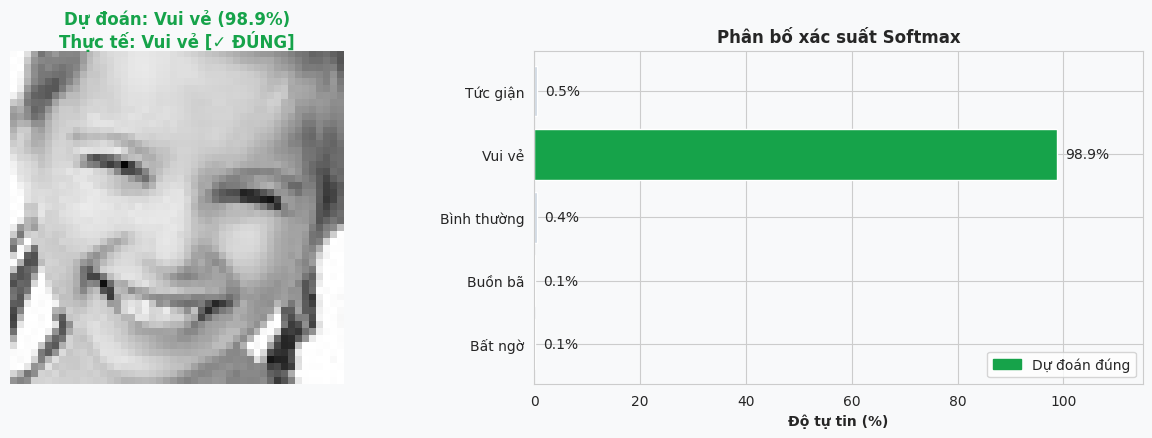

→ Dự đoán: Vui vẻ (98.9%) | Thực tế: Vui vẻ | ĐÚNG


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from tensorflow.keras.preprocessing import image
from google.colab import files

EMOTION_LABELS = list(train_generator.class_indices.keys())

EMOTION_MAP = {
    'angry': 'Tức giận',
    'happy': 'Vui vẻ',
    'neutral': 'Bình thường',
    'sad': 'Buồn bã',
    'surprise': 'Bất ngờ'
}

def test_and_visualize(img_path, true_emotion='unknown'):

    img_gray  = image.load_img(img_path, target_size=(48,48), color_mode='grayscale')
    img_array = image.img_to_array(img_gray)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    predictions   = best_model.predict(img_array, verbose=0)[0]
    max_index     = int(np.argmax(predictions))
    predicted_key = EMOTION_LABELS[max_index]
    predicted_vi  = EMOTION_MAP[predicted_key]
    confidence    = predictions[max_index] * 100

    true_emotion = true_emotion.lower()
    true_known   = true_emotion != 'unknown'

    if true_known and true_emotion in EMOTION_LABELS:
        true_index = EMOTION_LABELS.index(true_emotion)
        true_vi    = EMOTION_MAP[true_emotion]
        is_correct = (predicted_key == true_emotion)
    else:
        true_index = -1
        true_vi    = true_emotion
        is_correct = None

    MATCH_COLOR = '#16a34a'
    PRED_COLOR  = '#f97316'
    TRUE_COLOR  = '#2563eb'

    if is_correct is None:
        pred_color = '#1e40af'
        true_color = '#1e40af'
    elif is_correct:
        pred_color = MATCH_COLOR
        true_color = MATCH_COLOR
    else:
        pred_color = PRED_COLOR
        true_color = TRUE_COLOR

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.patch.set_facecolor('#f8f9fa')
    ax1.set_facecolor('#f8f9fa')
    ax2.set_facecolor('#f8f9fa')

    display_img = image.load_img(img_path)
    ax1.imshow(display_img)
    ax1.axis('off')

    if true_known:
        status_text = "✓ ĐÚNG" if is_correct else "✗ SAI"

        ax1.annotate(
            f"Dự đoán: {predicted_vi} ({confidence:.1f}%)",
            xy=(0.5, 1.08), xycoords='axes fraction',
            ha='center', fontsize=12, fontweight='bold',
            color=pred_color
        )

        ax1.annotate(
            f"Thực tế: {true_vi} [{status_text}]",
            xy=(0.5, 1.01), xycoords='axes fraction',
            ha='center', fontsize=12, fontweight='bold',
            color=true_color
        )
    else:
        ax1.annotate(
            f"Dự đoán: {predicted_vi} ({confidence:.1f}%)",
            xy=(0.5, 1.04), xycoords='axes fraction',
            ha='center', fontsize=13, fontweight='bold',
            color=pred_color
        )

    percentages = predictions * 100
    y_pos = np.arange(len(EMOTION_LABELS))

    bar_colors = []
    for i in range(len(EMOTION_LABELS)):
        if i == max_index and i == true_index:
            bar_colors.append(MATCH_COLOR)
        elif i == max_index:
            bar_colors.append(pred_color)
        elif i == true_index:
            bar_colors.append(true_color)
        else:
            bar_colors.append('#cbd5e1')

    bars = ax2.barh(y_pos, percentages, color=bar_colors)

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([EMOTION_MAP[e] for e in EMOTION_LABELS])
    ax2.invert_yaxis()
    ax2.set_xlabel('Độ tự tin (%)', fontweight='bold')
    ax2.set_title('Phân bố xác suất Softmax', fontweight='bold')
    ax2.set_xlim(0, 115)

    for i, v in enumerate(percentages):
        ax2.text(v + 1.5, i, f"{v:.1f}%", va='center', fontsize=10)

    if is_correct:
        legend = [mpatches.Patch(color=MATCH_COLOR, label='Dự đoán đúng')]
    elif true_known:
        legend = [
            mpatches.Patch(color=pred_color, label='Dự đoán'),
            mpatches.Patch(color=true_color, label='Thực tế')
        ]
    else:
        legend = [mpatches.Patch(color=pred_color, label='Dự đoán')]

    ax2.legend(handles=legend, loc='lower right')

    plt.tight_layout()
    plt.show()

    print(f"→ Dự đoán: {predicted_vi} ({confidence:.1f}%)"
          + (f" | Thực tế: {true_vi} | {'ĐÚNG' if is_correct else 'SAI'}"
             if true_known else ""))

print("Upload ảnh...")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nĐang xử lý: {filename}")

    test_and_visualize(filename, true_emotion='happy')

    os.remove(filename)